# MGT 209 Sales Driver Analysis

**Course:** MGT 209: Marketing Management, Winter 2023  
**Dataset:** `MGT 209 Assg 1 data.csv`

## Background

Analyze the dataset and answer three quantitative questions:

1. Using **descriptive statistics and correlation analysis only**, identify the top three drivers of `sales`.
2. Using **multiple regression** with `sales` as the dependent variable and the remaining variables as independent variables, identify the top three drivers and comment on the model outcome.
3. Determine whether any variables should be dropped; if so, drop them, rerun the regression, and comment on the revised model.


### Variable definitions

| Variable | Assignment description |
|---|---|
| Week | Week |
| sales | Unit sales |
| advertising | Advertising in $ |
| satisfaction | Overall satisfaction from a company selling a product / brand |
| ease_of_purchase | Ease of purchase and convenience related to buying a product / brand |
| searchoutcome | Overall positive perception after searching a product / brand |
| wom | Word of mouth regarding a product / brand |
| safety | Perceived safety in usage of a product / brand |
| reputation | Overall reputation of the firm selling a product / brand |

**Interpretation note.** `Week` is included in the regression because the assignment explicitly says to use the “remaining variables” as X variables and the original submitted answer corresponds to that specification. However, Week is treated as a **time/trend control**, not as a substantive marketing driver when ranking managerial drivers of sales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = "/mnt/data/MGT 209 Assg 1 data.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing"))


Dataset shape: (110, 9)


,Week,sales,satisfaction,advertising,ease_of_purchase,searchoutcome,wom,safety,reputation
0,1,834.5000,5.1000,264.3000,2.9000,1.3000,3.6000,2.8000,5.8000
1,2,921.8000,5.8000,280.4000,4.7000,4.9000,3.6000,4.6000,5.2000
2,3,"1,087.0000",4.4000,355.8000,4.9000,4.1000,3.1000,3.3000,6.2000
3,4,"1,078.6000",6.5000,290.3000,3.8000,4.2000,4.8000,2.2000,7.4000
4,5,968.2000,4.1000,302.7000,5.6000,4.1000,4.5000,4.7000,5.4000



Missing values:


,Missing
Week,0
sales,0
satisfaction,0
advertising,0
ease_of_purchase,0
searchoutcome,0
wom,0
safety,0
reputation,0


## 1. Descriptive statistics and correlation analysis

We first inspect the distribution of each variable, then calculate Pearson correlations with `sales`. Because Question 1 restricts the analysis to descriptive statistics and correlations, no regression results are used in this section.


In [2]:
desc = df.describe().T
display(desc)

corr_matrix = df.corr(numeric_only=True)
sales_corr = (
    corr_matrix["sales"]
    .drop("sales")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Correlations with sales (ranked by absolute correlation):")
display(sales_corr.to_frame("Correlation with sales"))


,count,mean,std,min,25%,50%,75%,max
Week,110.0000,55.5000,31.8983,1.0000,28.2500,55.5000,82.7500,110.0000
sales,110.0000,"1,001.5109",99.9995,733.9000,947.2250,"1,009.8000","1,060.1000","1,208.7000"
satisfaction,110.0000,4.9491,1.0216,2.9000,4.1250,5.0000,5.6000,7.2000
advertising,110.0000,299.1355,26.4903,233.7000,281.0500,296.1000,315.8250,362.5000
ease_of_purchase,110.0000,3.9118,0.9736,1.4000,3.3000,3.9000,4.5750,7.1000
searchoutcome,110.0000,4.8282,1.1460,1.3000,4.1000,4.9000,5.5750,7.2000
wom,110.0000,4.1273,0.9542,2.2000,3.4000,4.1500,4.7000,7.0000
safety,110.0000,3.7009,0.9041,1.6000,3.0000,3.7000,4.3000,6.3000
reputation,110.0000,5.5491,1.0800,2.5000,4.7250,5.6000,6.4000,8.1000


Correlations with sales (ranked by absolute correlation):


,Correlation with sales
advertising,0.6007
reputation,0.5007
satisfaction,0.4014
wom,0.2010
ease_of_purchase,0.1984
Week,0.1389
searchoutcome,0.0434
safety,0.0341


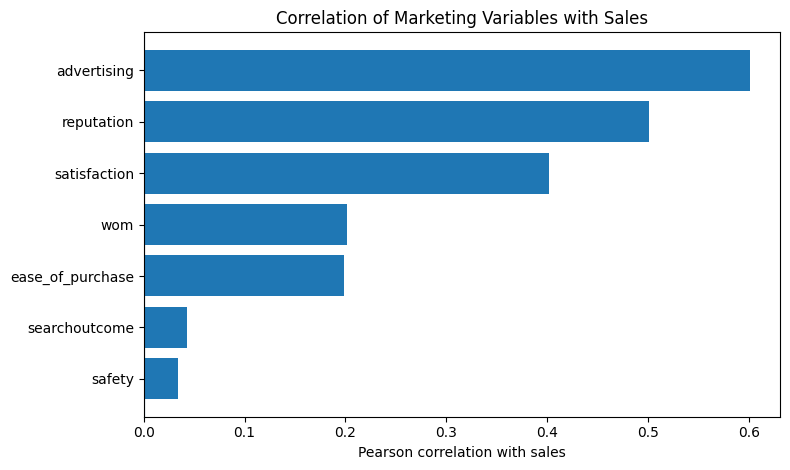

In [3]:
marketing_vars = [
    "satisfaction", "advertising", "ease_of_purchase",
    "searchoutcome", "wom", "safety", "reputation"
]
plot_corr = corr_matrix.loc[marketing_vars, "sales"].sort_values()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(plot_corr.index, plot_corr.values)
ax.axvline(0, linewidth=0.8)
ax.set_xlabel("Pearson correlation with sales")
ax.set_title("Correlation of Marketing Variables with Sales")
plt.tight_layout()
plt.show()


### Answer to Question 1

The **top three marketing drivers of sales by Pearson correlation** are:

1. **Advertising:** \(r = 0.601\)
2. **Reputation:** \(r = 0.501\)
3. **Satisfaction:** \(r = 0.401\)

`Week` is not treated as a marketing driver; it is simply the observation's time index.


## 2. Multiple regression

Following the assignment literally, we estimate:


Sales = beta_0 + beta_1 Week + beta_2 Satisfaction + beta_3 Advertising + beta_4 EaseOfPurchase + beta_5 SearchOutcome + beta_6 WOM + beta_7 Safety + beta_8 Reputation + epsilon

Raw regression coefficients are not directly comparable as measures of “importance” because the predictors use different units. Therefore, in addition to the regression, we calculate **standardized beta coefficients** solely to rank the substantive marketing drivers on a comparable scale.


In [4]:
X_cols = [c for c in df.columns if c != "sales"]
X = sm.add_constant(df[X_cols])
y = df["sales"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.227e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.96e-168
Time:                        10:38:11   Log-Likelihood:                -230.59
No. Observations:                 110   AIC:                             479.2
Df Residuals:                     101   BIC:                             503.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -541.9747      3.309  

In [5]:
reg_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std. Error": model.bse,
    "t": model.tvalues,
    "p-value": model.pvalues
})
display(reg_table)

print(f"R-squared: {model.rsquared:.6f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.6f}")
print(f"F-statistic: {model.fvalue:,.3f}")
print(f"Model p-value: {model.f_pvalue:.3e}")


,Coefficient,Std. Error,t,p-value
const,-541.9747,3.3089,-163.7953,0.0000
Week,1.1517,0.0064,180.3273,0.0000
satisfaction,41.7513,0.2025,206.2248,0.0000
advertising,2.6131,0.0078,335.1104,0.0000
ease_of_purchase,21.3040,0.2090,101.9505,0.0000
searchoutcome,-4.2415,0.1849,-22.9357,0.0000
wom,28.3286,0.2108,134.3731,0.0000
safety,10.7207,0.2292,46.7777,0.0000
reputation,48.9829,0.1849,264.9053,0.0000


R-squared: 0.999609
Adjusted R-squared: 0.999578
F-statistic: 32,267.578
Model p-value: 1.961e-168


In [6]:
# Standardized regression coefficients for comparable driver ranking
X_raw = df[X_cols]
X_z = (X_raw - X_raw.mean()) / X_raw.std(ddof=0)
y_z = (y - y.mean()) / y.std(ddof=0)

std_model = sm.OLS(y_z, sm.add_constant(X_z)).fit()
standardized = pd.DataFrame({
    "Standardized Beta": std_model.params.drop("const"),
    "p-value": std_model.pvalues.drop("const")
})
standardized["Absolute Beta"] = standardized["Standardized Beta"].abs()
standardized = standardized.sort_values("Absolute Beta", ascending=False)

display(standardized)

marketing_rank = standardized.drop(index="Week").copy()
print("Top three substantive marketing drivers:")
display(marketing_rank.head(3))


,Standardized Beta,p-value,Absolute Beta
advertising,0.6922,0.0000,0.6922
reputation,0.5290,0.0000,0.5290
satisfaction,0.4265,0.0000,0.4265
Week,0.3674,0.0000,0.3674
wom,0.2703,0.0000,0.2703
ease_of_purchase,0.2074,0.0000,0.2074
safety,0.0969,0.0000,0.0969
searchoutcome,-0.0486,0.0000,0.0486


Top three substantive marketing drivers:


,Standardized Beta,p-value,Absolute Beta
advertising,0.6922,0.0000,0.6922
reputation,0.5290,0.0000,0.5290
satisfaction,0.4265,0.0000,0.4265


### Answer to Question 2

The overall regression is statistically significant (**F = 32,267.58, p < 0.001**) and has **R² = 0.999609** and **Adjusted R² = 0.999578**. Thus, under the exact specification requested in the assignment, the model explains approximately **99.96%** of the sample variation in sales.

When the marketing variables are compared using standardized regression coefficients, the top three substantive drivers are:

1. **Advertising:** standardized \(eta = 0.692\), raw coefficient = 2.613
2. **Reputation:** standardized \(eta = 0.529\), raw coefficient = 48.983
3. **Satisfaction:** standardized \(eta = 0.427\), raw coefficient = 41.751

`Week` also has a large and highly significant standardized coefficient, but it represents a time trend rather than a managerial marketing driver.


## 3. Should any variables be dropped?

The assignment asks whether variables should be dropped and, **if yes**, to rerun the regression.

We can consider a predictor statistically significant when its p-value is below 0.05. We therefore inspect the p-values from the full model.


In [7]:
pvals = model.pvalues.drop("const").sort_values(ascending=False)
display(pvals.to_frame("p-value"))

alpha = 0.05
drop_candidates = pvals[pvals >= alpha]

if drop_candidates.empty:
    print("All predictor p-values are below 0.05.")
    print("No variables need to be dropped under the assignment's significance criterion.")
else:
    print("Candidates for removal at alpha = 0.05:")
    display(drop_candidates)


,p-value
searchoutcome,0.0000
safety,0.0000
ease_of_purchase,0.0000
wom,0.0000
Week,0.0000
satisfaction,0.0000
reputation,0.0000
advertising,0.0000


All predictor p-values are below 0.05.
No variables need to be dropped under the assignment's significance criterion.


### Answer to Question 3

**No variables need to be dropped under the course-style p-value criterion.** Every predictor in the specified full regression has a p-value below 0.05. Therefore, there is no statistically insignificant X variable to remove.

## Final Answers

**Q3.1 — Descriptive statistics and correlations:**  
The top three marketing variables associated with sales are **Advertising (r ≈ 0.601), Reputation (r ≈ 0.501), and Satisfaction (r ≈ 0.401)**.

**Q3.2 — Regression:**  
The multiple regression is highly statistically significant and explains approximately **99.96% of the variation in sales on an adjusted-R² basis**. Using standardized coefficients to compare predictors measured in different units, the top three substantive marketing drivers are **Advertising, Reputation, and Satisfaction**.

**Q3.3 — Variable removal:**  
**No.** All predictors are statistically significant at the 5% level in the assignment-specified model, so no variable is removed and a reduced regression is not required.

## Source / Provenance

- Assignment instructions: **MGT 209 Assignment 1, Winter 2023**.
- Dataset: **MGT 209 Assg 1 data.csv**, 110 observations.